# Occupations over time
Tracks the share of active individuals per occupation over time and maps astronomer co-occupation networks.

In [1]:
import random
import tempfile
from collections import Counter
from itertools import combinations

import duckdb
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
from style import *

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'

apply_style()

## Parameters

In [2]:
WORLD_RANGE = (-500, 2018)
POLITY_NAMES = ['Roman Empire', 'Tang Dynasty']

TOP_OCCUPATIONS_PER_CENTURY = 10
MAX_OCCUPATIONS_PER_SCOPE = 20
BUCKET_YEARS = 50

ASTRONOMER_PERIODS = {
    '750 – 1250':  (750, 1250),
    '1400 – 1650': (1400, 1650),
    '1750 – 1950': (1750, 1950),
}
ASTRONOMER_VARIANTS = ['amateur astronomer', 'radio astronomer', 'archaeoastronomer', 'astronomer royal']

NETWORK_NODE_COUNT = 15
NETWORK_MIN_EDGE_COUNT = 2

## Load data
### Occupations per individual

In [3]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")

con.sql("""
    CREATE TEMP TABLE people AS
    SELECT entity.qid                   AS qid,
           peak_productivity.start_year AS peak_start,
           peak_productivity.end_year   AS peak_end
    FROM   individual_enriched
    WHERE  peak_productivity.start_year IS NOT NULL
""")

con.sql("""
    CREATE TEMP TABLE individual_occupation AS
    SELECT entity.qid                    AS qid,
           unnest(occupation).entity.qid AS occupation_qid
    FROM   individual
    WHERE  len(occupation) > 0
""")

con.sql("""
    CREATE TEMP TABLE occupation_rows AS
    SELECT DISTINCT
           'World'                    AS scope,
           people.qid                 AS qid,
           people.peak_start          AS peak_start,
           people.peak_end            AS peak_end,
           occupation.entity.label_en AS occupation
    FROM   people
    JOIN   individual_occupation USING (qid)
    JOIN   occupation ON occupation.entity.qid = individual_occupation.occupation_qid
    WHERE  occupation.entity.label_en IS NOT NULL
""")

world_overview = con.sql("""
    SELECT COUNT(*)            AS occupation_rows,
           COUNT(DISTINCT qid) AS individuals,
           MIN(peak_start)     AS min_start,
           MAX(peak_end)       AS max_end
    FROM   occupation_rows
    WHERE  scope = 'World'
""").pl()
world_overview

occupation_rows,individuals,min_start,max_end
i64,i64,i64,i64
10714818,7408440,-8967,2026


### Polity year spans

In [4]:
polity_year_spans = con.sql("""
    SELECT   name                      AS polity_name,
             MIN(territory.start_year) AS polity_start,
             MAX(territory.end_year)   AS polity_end
    FROM     polity, unnest(territories) AS unnested(territory)
    WHERE    list_contains($names, name)
    GROUP BY name
    ORDER BY name
""", params={'names': POLITY_NAMES}).pl()

assert polity_year_spans.height == len(POLITY_NAMES)
polity_to_year_range = {
    row['polity_name']: ((row['polity_start'] // 100) * 100, ((row['polity_end'] + 99) // 100) * 100 - 1)
    for row in polity_year_spans.iter_rows(named=True)
}
ROMAN_RANGE = polity_to_year_range['Roman Empire']
TANG_RANGE = polity_to_year_range['Tang Dynasty']
print('ROMAN_RANGE:', ROMAN_RANGE, ' TANG_RANGE:', TANG_RANGE)
polity_year_spans

ROMAN_RANGE: (-100, 399)  TANG_RANGE: (600, 999)


polity_name,polity_start,polity_end
str,i64,i64
"""Roman Empire""",-31,394
"""Tang Dynasty""",623,910


### Polity cohorts

In [5]:
con.sql("""
    CREATE TEMP TABLE individual_polity AS
    SELECT entity.qid                 AS qid,
           unnest(polity).polity.name AS polity_name
    FROM   individual_enriched
""")

con.sql("""
    INSERT INTO occupation_rows
    SELECT DISTINCT
           individual_polity.polity_name AS scope,
           occupation_rows.qid,
           occupation_rows.peak_start,
           occupation_rows.peak_end,
           occupation_rows.occupation
    FROM   occupation_rows
    JOIN   individual_polity USING (qid)
    WHERE  occupation_rows.scope = 'World'
      AND  list_contains($names, individual_polity.polity_name)
""", params={'names': POLITY_NAMES})

OCCUPATION_ROWS_OF_SCOPE = """
    SELECT qid, peak_start, peak_end, occupation
    FROM   occupation_rows
    WHERE  scope = $scope
"""
occupation_rows_roman = con.sql(OCCUPATION_ROWS_OF_SCOPE, params={'scope': 'Roman Empire'}).pl()
occupation_rows_tang = con.sql(OCCUPATION_ROWS_OF_SCOPE, params={'scope': 'Tang Dynasty'}).pl()

for name, rows in [('Roman Empire', occupation_rows_roman), ('Tang Dynasty', occupation_rows_tang)]:
    print(f'{name:13s}: {rows.height:,} occupation rows, {rows["qid"].n_unique():,} individuals')
occupation_rows_tang.head()

Roman Empire : 5,273 occupation rows, 3,648 individuals
Tang Dynasty : 2,749 occupation rows, 2,132 individuals


qid,peak_start,peak_end,occupation
str,i64,i64,str
"""Q11097798""",833,847,"""military personnel"""
"""Q135419595""",781,798,"""bureaucrat"""
"""Q16904214""",864,878,"""military personnel"""
"""Q18383901""",773,790,"""politician"""
"""Q16200780""",902,916,"""politician"""


### Astronomers

In [6]:
astronomer_individuals = con.sql("""
    SELECT   qid,
             peak_start,
             list(occupation ORDER BY occupation) AS occupations
    FROM     occupation_rows
    WHERE    scope = 'World'
    GROUP BY qid, peak_start
    HAVING   bool_or(occupation LIKE '%astronomer%')
""").pl()

assert astronomer_individuals['qid'].is_unique
print('shape:', astronomer_individuals.shape)
astronomer_individuals.head()

shape: (11067, 3)


qid,peak_start,occupations
str,i64,list[str]
"""Q134533128""",1905,"[""archaeologist"", ""astronomer"", … ""mathematician""]"
"""Q6384718""",1983,"[""astronomer""]"
"""Q65350""",1944,"[""astronomer"", ""nuclear physicist"", … ""writer""]"
"""Q78169818""",1986,"[""astronomer""]"
"""Q451390""",-324,"[""astronomer"", ""mathematician""]"


## Preprocessing
### Top occupations per scope

In [7]:
def top_occupations(scope, year_range):
    lo, hi = year_range
    con.sql("""
        CREATE OR REPLACE TEMP TABLE century_ranks AS
        SELECT   CAST(floor(peak_start / 100) * 100 AS BIGINT) AS century,
                 occupation,
                 COUNT(*) AS n,
                 row_number() OVER (PARTITION BY century ORDER BY COUNT(*) DESC, occupation) AS rank_in_century
        FROM     occupation_rows
        WHERE    scope = $scope
          AND    peak_start BETWEEN $lo AND $hi
        GROUP BY century, occupation
    """, params={'scope': scope, 'lo': lo, 'hi': hi})

    return con.sql("""
        SELECT   occupation,
                 CAST(SUM(n) AS BIGINT) AS total_individuals,
                 MIN(rank_in_century)   AS best_rank
        FROM     century_ranks
        WHERE    rank_in_century <= $top
        GROUP BY occupation
        ORDER BY total_individuals DESC, best_rank, occupation
        LIMIT    $limit
    """, params={'top': TOP_OCCUPATIONS_PER_CENTURY, 'limit': MAX_OCCUPATIONS_PER_SCOPE}).pl()

world_top = top_occupations('World', WORLD_RANGE)
roman_top = top_occupations('Roman Empire', ROMAN_RANGE)
tang_top = top_occupations('Tang Dynasty', TANG_RANGE)

for name, top in [('world', world_top), ('roman', roman_top), ('tang', tang_top)]:
    assert top['occupation'].is_unique
    print(f'{name}: {top.height} occupations')
world_top.head(10)

world: 20 occupations
roman: 20 occupations
tang: 17 occupations


occupation,total_individuals,best_rank
str,i64,i64
"""researcher""",1425474,1
"""politician""",701414,1
"""writer""",344352,2
"""university teacher""",243161,3
"""association football player""",239438,2
"""actor""",200525,4
"""painter""",192703,2
"""journalist""",154730,7
"""poet""",92604,1


### Active individuals per year

In [8]:
def active_per_year(scope, top, year_range):
    lo, hi = year_range
    order = top['occupation'].to_list() + ['Other']
    spans = con.sql("""
        SELECT   CASE WHEN list_contains($top, occupation) THEN occupation ELSE 'Other' END AS occupation_group,
                 greatest(peak_start, $lo) AS active_start,
                 least(peak_end, $hi)      AS active_end,
                 COUNT(*)                  AS row_count
        FROM     occupation_rows
        WHERE    scope = $scope
          AND    greatest(peak_start, $lo) <= least(peak_end, $hi)
        GROUP BY occupation_group, active_start, active_end
    """, params={'scope': scope, 'top': order[:-1], 'lo': lo, 'hi': hi}).pl()

    years = np.arange(lo, hi + 2)
    counts = {}
    for occupation in order:
        s = spans.filter(pl.col('occupation_group') == occupation)
        delta = np.zeros(len(years), dtype=np.int64)
        np.add.at(delta, s['active_start'].to_numpy() - lo, s['row_count'].to_numpy())
        np.add.at(delta, s['active_end'].to_numpy() + 1 - lo, -s['row_count'].to_numpy())
        counts[occupation] = np.cumsum(delta)[:-1]
    return pl.DataFrame({'year': years[:-1], **counts}), order

world_active, world_order = active_per_year('World', world_top, WORLD_RANGE)
roman_active, roman_order = active_per_year('Roman Empire', roman_top, ROMAN_RANGE)
tang_active, tang_order = active_per_year('Tang Dynasty', tang_top, TANG_RANGE)

con.close()

assert (world_active.drop('year').to_numpy() >= 0).all()
print('world shape:', world_active.shape)
world_active.head()

world shape: (2519, 22)


year,researcher,politician,writer,university teacher,association football player,actor,painter,journalist,poet,historian,basketball player,film director,military personnel,singer,Catholic priest,physician,lawyer,Catholic bishop,teacher,architect,Other
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
-500,0,137,25,1,0,1,10,1,23,10,0,1,106,0,0,4,0,0,1,8,567
-499,0,71,19,1,0,1,6,1,19,8,0,1,57,0,0,3,0,0,1,5,463
-498,0,70,19,1,0,1,6,1,19,8,0,1,57,0,0,2,0,0,1,5,462
-497,0,68,21,1,0,1,6,1,21,8,0,1,55,0,0,2,0,0,1,5,462
-496,0,66,21,1,0,1,6,1,21,8,0,1,55,0,0,2,0,0,1,5,460


### Occupation shares per 50-year bucket

In [9]:
def bucket_shares(active, order):
    lo, hi = active['year'].min(), active['year'].max()
    bucketed = (
        active
        .with_columns(((pl.col('year') - lo) // BUCKET_YEARS * BUCKET_YEARS + lo).alias('bucket'))
        .group_by('bucket').agg(pl.len().alias('n_years'), *[pl.col(o).mean() for o in order])
        .sort('bucket')
    )
    complete = bucketed.filter(pl.col('n_years') == BUCKET_YEARS)
    print(f'buckets: {bucketed.height} -> {complete.height} complete ({complete["bucket"].min()}–{complete["bucket"].max() + BUCKET_YEARS - 1})')
    total = pl.sum_horizontal(order)
    return (complete.with_columns(total.alias('total'))
                    .filter(pl.col('total') > 0)
                    .with_columns([(pl.col(o) / pl.col('total')).alias(o) for o in order]))

world_shares = bucket_shares(world_active, world_order)
roman_shares = bucket_shares(roman_active, roman_order)
tang_shares = bucket_shares(tang_active, tang_order)

assert np.allclose(world_shares.select(world_order).to_numpy().sum(axis=1), 1)
world_shares.head()

buckets: 51 -> 50 complete (-500–1999)


buckets: 10 -> 10 complete (-100–399)
buckets: 8 -> 8 complete (600–999)


bucket,n_years,researcher,politician,writer,university teacher,association football player,actor,painter,journalist,poet,historian,basketball player,film director,military personnel,singer,Catholic priest,physician,lawyer,Catholic bishop,teacher,architect,Other,total
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-500,50,0.0,0.142217,0.044572,0.001673,0.0,0.001673,0.015962,0.001673,0.032258,0.01218,0.0,0.001673,0.116651,0.0,0.0,0.004752,0.0,0.0,0.001305,0.006224,0.617186,597.68
-450,50,0.0,0.150976,0.049457,0.001691,0.0,0.003552,0.014309,0.001691,0.027063,0.020229,0.0,0.001691,0.127533,0.0,0.0,0.008728,0.0,0.0,0.001861,0.007882,0.583336,591.22
-400,50,0.0,0.108892,0.048029,0.001637,0.0,0.004682,0.018236,0.001637,0.034999,0.033002,0.0,0.001637,0.104931,0.000033,0.0,0.010837,0.000131,0.0,0.0,0.011983,0.619336,610.88
-350,50,0.0,0.091571,0.061377,0.001544,0.0,0.002192,0.016301,0.001544,0.037234,0.053597,0.0,0.001544,0.103026,0.0,0.0,0.012473,0.00071,0.0,0.0,0.008861,0.608027,647.8
-300,50,0.0,0.110964,0.08124,0.001695,0.0,0.001695,0.017522,0.001695,0.062871,0.051313,0.0,0.001695,0.100322,0.0,0.0,0.016099,0.0,0.0,0.005321,0.008541,0.539027,590.1


### Shared occupation palette

In [10]:
all_occupations = list(dict.fromkeys(world_order[:-1] + roman_order[:-1] + tang_order[:-1]))
occupation_palette = categorical_palette(all_occupations)
occupation_palette['Other'] = OTHER_CATEGORY_COLOR
print(f'shared palette: {len(all_occupations)} occupations + Other')

shared palette: 41 occupations + Other


In [11]:
def format_year(year):
    year = int(round(year))
    return f'{abs(year)} BCE' if year < 0 else f'{year}'


def plot_share_area(shares, order, scope_name, log_time=False, ref_year=2020, tick_years=None):
    mids = shares['bucket'].to_numpy() + BUCKET_YEARS / 2
    x = -np.log10(ref_year - mids) if log_time else mids
    if tick_years is None:
        tick_years = shares['bucket'].to_list()
    ticks = [-np.log10(ref_year - y) for y in tick_years] if log_time else tick_years

    fig, ax = plt.subplots(figsize=(16, 7.5))
    ax.stackplot(x, shares.select(order).to_numpy().T, labels=order,
                 colors=[occupation_palette[o] for o in order], edgecolor=BACKGROUND_COLOR, linewidth=0.2, alpha=0.9)
    ax.set_xticks(ticks)
    ax.set_xticklabels([format_year(y) for y in tick_years], rotation=30, ha='right')
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, 1)
    ax.set_xlabel('Year (log time)' if log_time else 'Year')
    fig.suptitle(scope_name, fontsize=POLITY_TITLE_FONTSIZE, y=0.98)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], loc='upper left', bbox_to_anchor=(1.01, 1.0),
              borderaxespad=0, handlelength=1.2, labelspacing=0.4)
    fig.subplots_adjust(left=0.06, right=0.78, top=0.91, bottom=0.16)
    plt.show()

## Figures
### World

### World

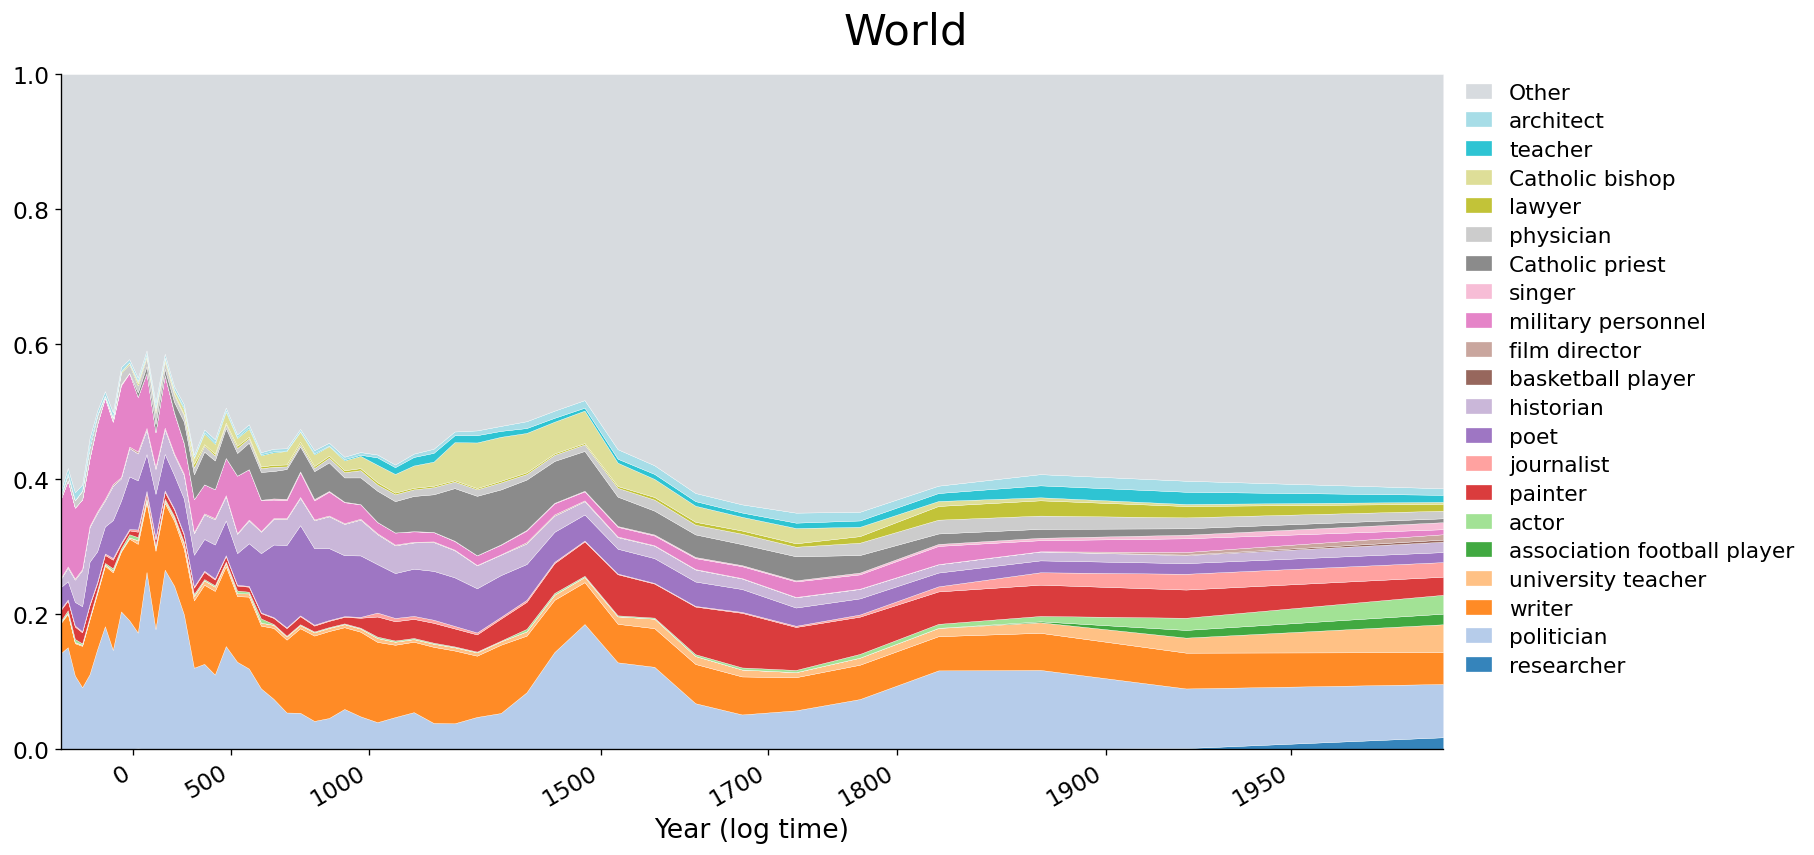

In [12]:
plot_share_area(world_shares, world_order, 'World', log_time=True,
                tick_years=[0, 500, 1000, 1500, 1700, 1800, 1900, 1950])

### Roman Empire

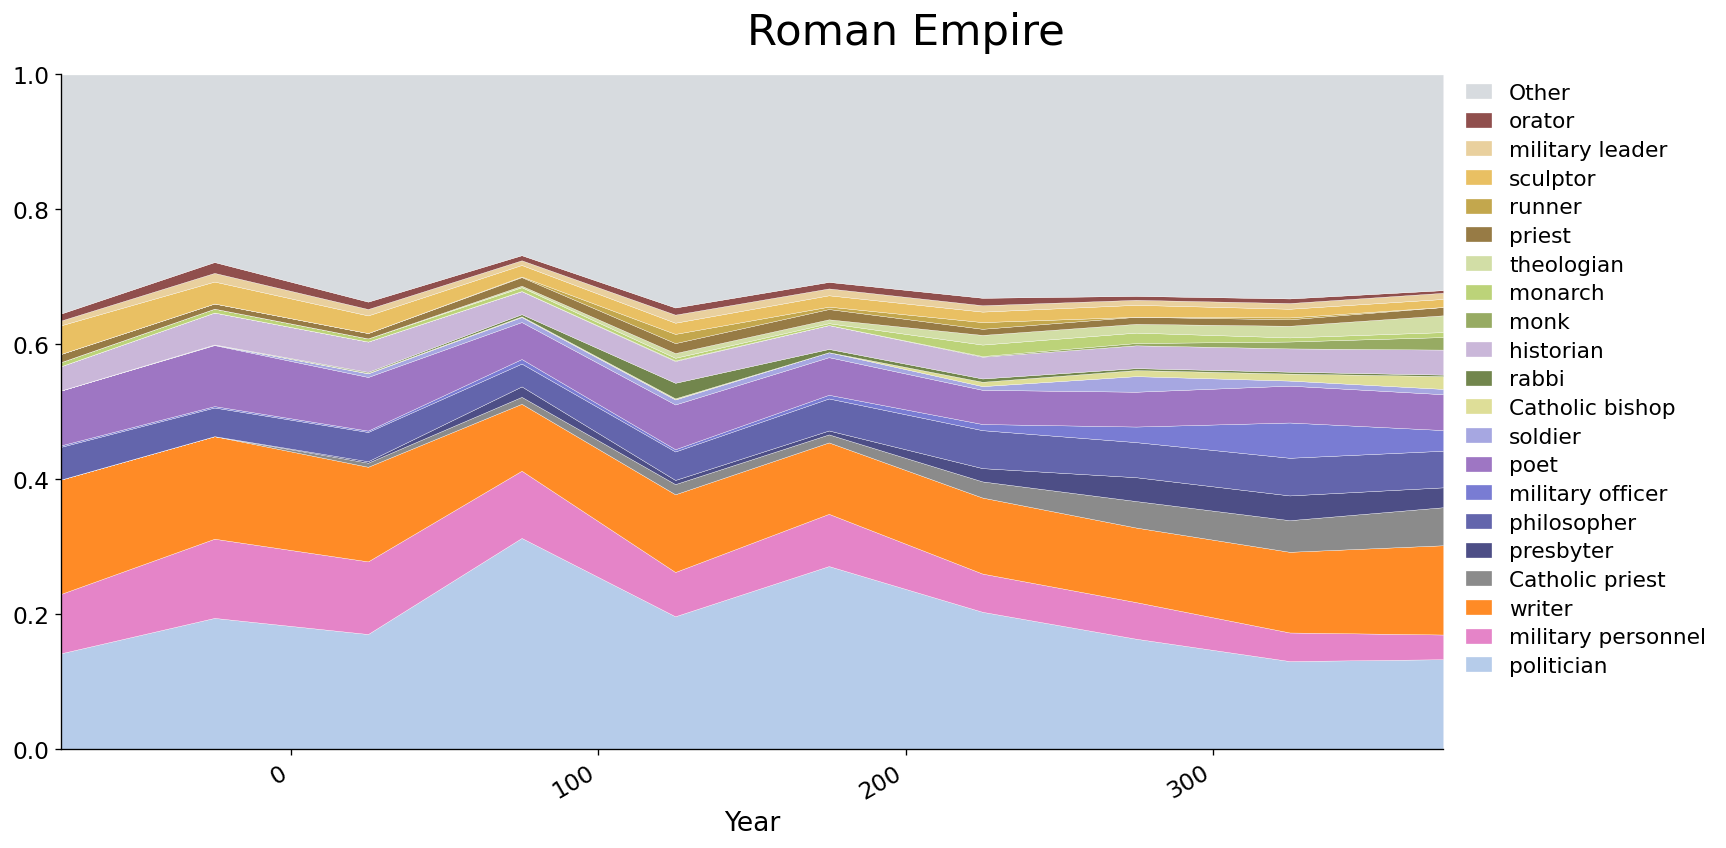

In [13]:
plot_share_area(roman_shares, roman_order, 'Roman Empire',
                tick_years=list(range(ROMAN_RANGE[0], ROMAN_RANGE[1] + 1, 100)))

### Tang Dynasty

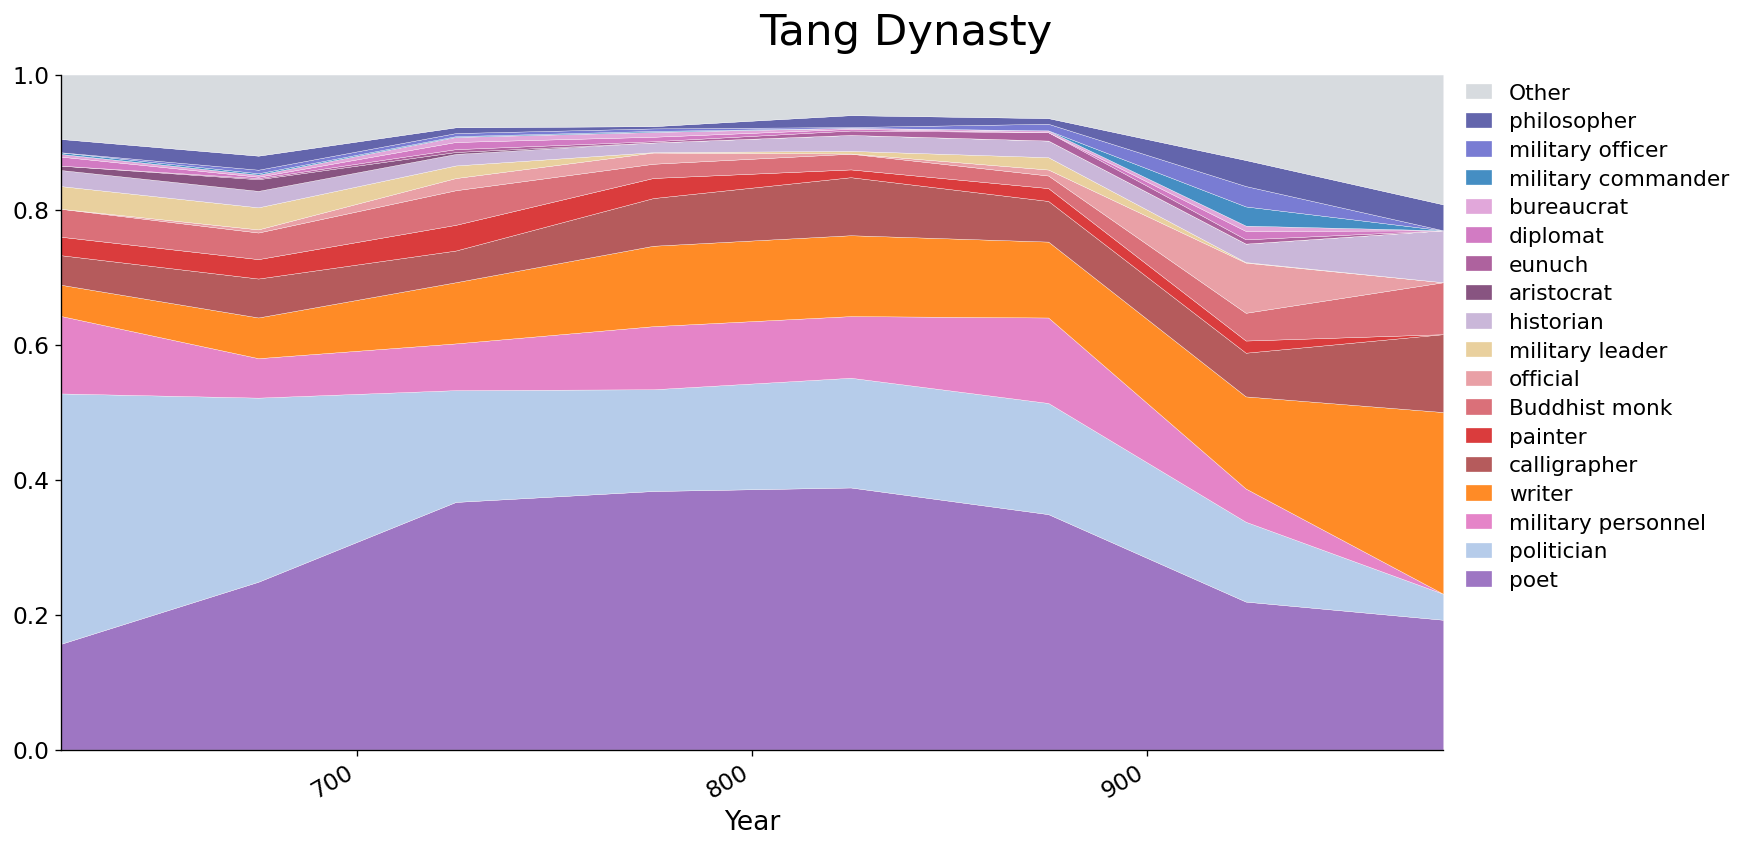

In [14]:
plot_share_area(tang_shares, tang_order, 'Tang Dynasty',
                tick_years=list(range(TANG_RANGE[0], TANG_RANGE[1] + 1, 100)))

## Astronomer co-occupations
### Cohorts per period

In [15]:
period_of = pl.lit(None, dtype=pl.Utf8)
for label, (lo, hi) in reversed(ASTRONOMER_PERIODS.items()):
    period_of = pl.when(pl.col('peak_start').is_between(lo, hi)).then(pl.lit(label)).otherwise(period_of)

astronomers_with_period = astronomer_individuals.with_columns(period_of.alias('period')).filter(pl.col('period').is_not_null())
print(f'astronomers: {astronomer_individuals.height:,} -> {astronomers_with_period.height:,} within the three periods')

astronomers_per_period = astronomers_with_period.group_by('period').len().rename({'len': 'astronomer_count'}).sort('period')
astronomers_per_period

astronomers: 11,067 -> 4,382 within the three periods


period,astronomer_count
str,u32
"""1400 – 1650""",641
"""1750 – 1950""",3560
"""750 – 1250""",181


In [16]:
occupation_counts_per_period = {label: Counter() for label in ASTRONOMER_PERIODS}
pair_counts_per_period = {label: Counter() for label in ASTRONOMER_PERIODS}

for row in astronomers_with_period.iter_rows(named=True):
    occupations = [o for o in row['occupations'] if o.lower() not in ASTRONOMER_VARIANTS]
    occupation_counts_per_period[row['period']].update(occupations)
    pair_counts_per_period[row['period']].update(combinations(sorted(occupations), 2))

top_cooccupations = pl.concat([
    pl.DataFrame(occupation_counts_per_period[p].most_common(NETWORK_NODE_COUNT),
                 schema=['occupation', 'individual_count'], orient='row').with_columns(pl.lit(p).alias('period'))
    for p in ASTRONOMER_PERIODS
]).select('period', 'occupation', 'individual_count')

for p in ASTRONOMER_PERIODS:
    print(f'{p:13s}: {len(occupation_counts_per_period[p]):4d} unique occupations, {len(pair_counts_per_period[p]):5d} unique pairs')
top_cooccupations.head(10)

750 – 1250   :  104 unique occupations,   880 unique pairs
1400 – 1650  :  205 unique occupations,  1666 unique pairs
1750 – 1950  :  443 unique occupations,  3127 unique pairs


period,occupation,individual_count
str,str,i64
"""750 – 1250""","""astronomer""",181
"""750 – 1250""","""mathematician""",91
"""750 – 1250""","""astrologer""",74
"""750 – 1250""","""philosopher""",34
"""750 – 1250""","""writer""",32
"""750 – 1250""","""physician""",25
"""750 – 1250""","""poet""",21
"""750 – 1250""","""translator""",18
"""750 – 1250""","""physicist""",12


### Astronomer co-occupation networks

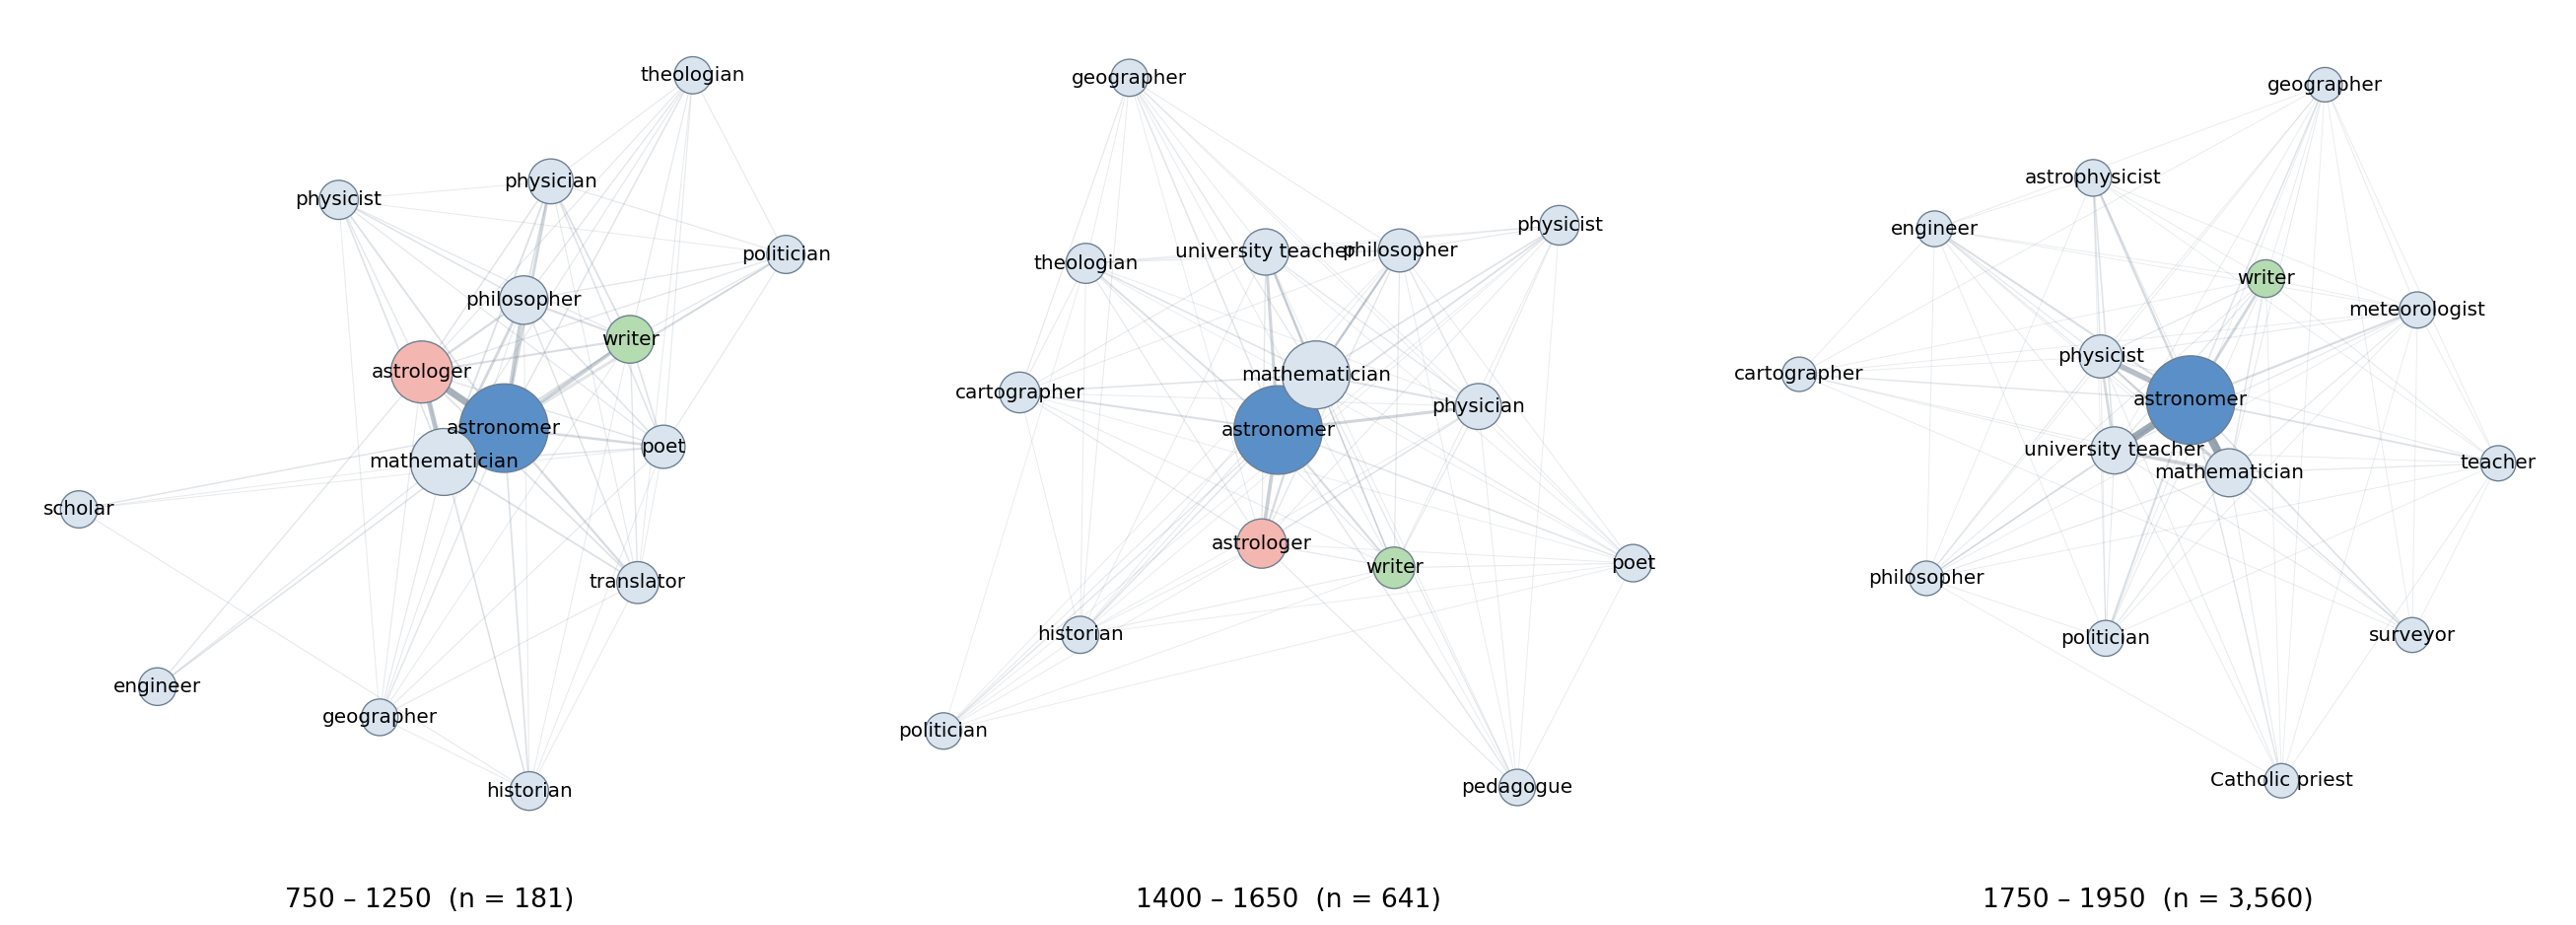

In [17]:
def node_color(occupation):
    return ASTRONOMER_NETWORK_COLORS.get(occupation, ASTRONOMER_NETWORK_COLORS['other_node'])

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
for ax, period in zip(axes, ASTRONOMER_PERIODS):
    counts = occupation_counts_per_period[period]
    top = [o for o, _ in counts.most_common(NETWORK_NODE_COUNT)]
    if 'astronomer' not in top:
        top = ['astronomer'] + top[:NETWORK_NODE_COUNT - 1]

    graph = nx.Graph()
    graph.add_nodes_from((o, {'count': counts[o]}) for o in top)
    graph.add_edges_from((a, b, {'weight': w}) for (a, b), w in pair_counts_per_period[period].items()
                         if a in graph and b in graph and w >= NETWORK_MIN_EDGE_COUNT)
    layout = nx.spring_layout(graph, k=2.0, iterations=150, seed=SEED, weight='weight')

    max_count = max(nx.get_node_attributes(graph, 'count').values())
    weights = [graph.edges[e]['weight'] for e in graph.edges()]
    max_weight = max(weights) if weights else 1
    for edge, w in zip(graph.edges(), weights):
        nx.draw_networkx_edges(graph, layout, edgelist=[edge], ax=ax, width=0.5 + 4.5 * w / max_weight,
                               edge_color=ASTRONOMER_NETWORK_COLORS['edge'], alpha=0.15 + 0.55 * w / max_weight)
    nx.draw_networkx_nodes(graph, layout, ax=ax, node_size=[400 + 2500 * graph.nodes[n]['count'] / max_count for n in graph],
                           node_color=[node_color(n) for n in graph], edgecolors=ASTRONOMER_NETWORK_COLORS['node_edge'], linewidths=0.8)
    nx.draw_networkx_labels(graph, layout, ax=ax, font_size=VALUE_LABEL_FONTSIZE)

    n = astronomers_per_period.filter(pl.col('period') == period)['astronomer_count'].item()
    ax.text(0.5, -0.04, f'{period}  (n = {n:,})', transform=ax.transAxes, ha='center', va='top', fontsize=PANEL_LABEL_FONTSIZE)
    ax.axis('off')

plt.tight_layout()
plt.show()